# Slerp: Interpolación Esférica Lineal

- Autor: Julian Andres Gomez Niño
- Computación Gráfica
- Universidad Nacional de Colombia

In [1]:
import importlib.util
import subprocess
import sys

In [2]:
missing = [
    pkg
    for pkg in ("manim", "numpy", "scipy", "matplotlib", "imageio_ffmpeg")
    if importlib.util.find_spec(pkg) is None
]
if missing:
    # Manim Community se instala como 'manim' y el conversor como 'imageio-ffmpeg'.
    packages = {
        "manim": "manim",
        "numpy": "numpy",
        "scipy": "scipy",
        "matplotlib": "matplotlib",
        "imageio_ffmpeg": "imageio-ffmpeg",
    }
    command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        *[packages[pkg] for pkg in missing],
    ]
    print("Instalando: " + ", ".join(missing))
    print("Comando: " + " ".join(command))
    subprocess.check_call(command)

import os
from pathlib import Path

import numpy as np
import scipy
import scipy.spatial.transform as st
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Video, HTML

In [3]:
from manim import config

config.pixel_height = 480          # 480p
config.pixel_width = 854           # 16:9
config.frame_rate = 15             # fps bajo para velocidad
config.media_dir = "media"         # carpeta de salida
config.preview = False             # no abrir ventana externa
config.write_to_movie = True
config.disable_caching = True

In [4]:
BLUE = "#2a78d6"
YELLOW = "#eda100"
GREEN = "#1baf7a"
RED = "#e34948"
WHITE = "#ffffff"

In [5]:
import shutil

plt.style.use("dark_background")
plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.labelcolor": "#c3c2b7",
    "xtick.color": "#c3c2b7",
    "ytick.color": "#c3c2b7",
    "text.color": "#ffffff",
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor": "#0d0d0d",
})

def encontrar_video(nombre_escena):
    """Encuentra el MP4 generado por Manim en cualquier calidad."""
    base = Path("media") / "videos"
    nombres = {nombre_escena, f"{nombre_escena}.mp4"}
    matches = sorted(
        path for path in base.rglob("*.mp4")
        if path.name in nombres
    ) if base.exists() else []

    if not matches:
        raise FileNotFoundError(
            f"No se encontró el video de la escena {nombre_escena!r} "
            f"dentro de {base.resolve()}"
        )
    return str(matches[0])

def video_compatible(path):
    """Convierte el MP4 a un formato reproducible en VS Code y Colab."""
    source = Path(path)
    target = source.with_name(f"{source.stem}_browser.mp4")

    if target.exists() and target.stat().st_mtime >= source.stat().st_mtime:
        return str(target)

    ffmpeg = shutil.which("ffmpeg")
    if ffmpeg is None:
        try:
            import imageio_ffmpeg
            ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
        except ImportError as exc:
            raise RuntimeError(
                "No se encontró ffmpeg. En Colab ejecute "
                "!apt-get -qq update && apt-get -qq install -y ffmpeg."
            ) from exc

    command = [
        ffmpeg,
        "-y",
        "-i", str(source),
        "-c:v", "libx264",
        "-profile:v", "baseline",
        "-level", "3.0",
        "-pix_fmt", "yuv420p",
        "-movflags", "+faststart",
        "-an",
        str(target),
    ]
    subprocess.run(command, check=True, capture_output=True, text=True)
    return str(target)

def mostrar_video(path):
    """Reproduce un MP4 compatible dentro de VS Code o Google Colab."""
    return Video(
        video_compatible(path),
        embed=True,
        mimetype="video/mp4",
        html_attributes="controls playsinline width=520",
    )

print("Entorno listo.")
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"SciPy: {scipy.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
try:
    import manim
    print(f"manim-ce: {manim.__version__}")
except Exception as exc:
    print(f"manim-ce: no disponible ({exc})")

Entorno listo.
Python: 3.13.7
NumPy: 2.3.3
SciPy: 1.18.1
Matplotlib: 3.10.6
manim-ce: 0.21.0


## 1. Motivación

¿Por qué la interpolación lineal (lerp) falla para rotaciones?

Imagina dos orientaciones representadas como puntos en una esfera: $S^3$ para cuaterniones unitarios y $S^2$ para ejes-ángulo.
Si interpolamos linealmente entre ellos (lerp), los puntos intermedios caen dentro de la esfera (norma menor que 1).
Al renormalizar (nlerp) forzamos la norma a 1, pero la velocidad angular no es constante: el punto se mueve más rápido cerca de los extremos y más lento en el medio.

En la siguiente animación vemos esto en 2D (círculo unitario $S^1$): el punto rojo (lerp) se hunde dentro del círculo, mientras el verde (slerp) se mantiene en el arco y avanza a velocidad constante.

In [6]:
from manim import *

class LerpVsSlerpS1(Scene):
    def construct(self):
        self.camera.background_color = "#0d0d0d"
        title = Text("Lerp vs. Slerp en el círculo unitario", font_size=28)
        title.to_edge(UP)
        self.add(title)

        radius = 2.4
        angle0 = 0.0
        angle1 = np.deg2rad(120)
        q0 = np.array([np.cos(angle0), np.sin(angle0), 0.0])
        q1 = np.array([np.cos(angle1), np.sin(angle1), 0.0])

        circle = Circle(radius=radius, color=WHITE, stroke_width=2)
        self.add(circle)

        dot_q0 = Dot(point=radius * q0, color=BLUE, radius=0.10)
        dot_q1 = Dot(point=radius * q1, color=YELLOW, radius=0.10)
        label_q0 = MathTex("q_0").next_to(dot_q0, LEFT + DOWN, buff=0.12)
        label_q1 = MathTex("q_1").next_to(dot_q1, RIGHT + UP, buff=0.12)
        self.add(dot_q0, dot_q1, label_q0, label_q1)

        arc = Arc(start_angle=angle0, angle=angle1, radius=radius, color=GREEN, stroke_width=4)
        chord = Line(radius * q0, radius * q1, color=RED, stroke_width=2, stroke_opacity=0.65)
        self.add(chord, arc)

        tracker = ValueTracker(0.0)
        omega = angle1 - angle0

        def lerp_position():
            t = tracker.get_value()
            return radius * ((1 - t) * q0 + t * q1)

        def slerp_position():
            theta = tracker.get_value() * omega
            return radius * np.array([np.cos(theta), np.sin(theta), 0.0])

        lerp_dot = Dot(color=RED, radius=0.11)
        slerp_dot = Dot(color=GREEN, radius=0.11)
        lerp_dot.add_updater(lambda mob: mob.move_to(lerp_position()))
        slerp_dot.add_updater(lambda mob: mob.move_to(slerp_position()))
        self.add(lerp_dot, slerp_dot)

        lerp_label = MathTex(r"\text{lerp}", color=RED)
        slerp_label = MathTex(r"\text{slerp}", color=GREEN)
        lerp_label.add_updater(lambda mob: mob.next_to(lerp_dot, DOWN, buff=0.12))
        slerp_label.add_updater(lambda mob: mob.next_to(slerp_dot, UP, buff=0.12))
        self.add(lerp_label, slerp_label)

        norm_label = MathTex(r"\lVert q_{\mathrm{lerp}}(t) \rVert =")
        norm_value = DecimalNumber(1.0, num_decimal_places=3, color=RED)
        norm_group = VGroup(norm_label, norm_value).arrange(RIGHT, buff=0.12)
        norm_group.to_corner(UL).shift(DOWN * 0.55)
        norm_value.add_updater(lambda mob: mob.set_value(np.linalg.norm(lerp_position() / radius)))
        self.add(norm_group)

        legend = VGroup(
            MathTex(r"\text{lerp}", color=RED),
            MathTex(r"\text{slerp}", color=GREEN),
        ).arrange(DOWN, aligned_edge=LEFT, buff=0.08)
        legend.to_corner(UR).shift(DOWN * 0.55)
        self.add(legend)

        self.wait(0.5)
        self.play(tracker.animate.set_value(1.0), run_time=4, rate_func=linear)
        self.wait(0.5)

In [7]:
scene = LerpVsSlerpS1()
scene.render()
mostrar_video(encontrar_video("LerpVsSlerpS1"))

[09/23/26 09:20:57] INFO     Caching disabled.                                                 cairo_renderer.py:81

                    INFO     Animation 0 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\LerpVsS                         
                             lerpS1\uncached_00000.mp4'                                                            

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 09:21:02] INFO     Animation 1 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\LerpVsS                         
                             lerpS1\uncached_00001.mp4'                                                            

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

                    INFO     Animation 2 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\LerpVsS                         
                             lerpS1\uncached_00002.mp4'                                                            

                    INFO     Combining to Movie file.                                      scene_file_writer.py:952

[09/23/26 09:21:03] INFO                                                                  scene_file_writer.py:1103
                             File ready at 'C:\Users\Julian Gomez\Desktop\computacion                              
                             grafica\slerp\media\videos\480p15\LerpVsSlerpS1.mp4'                                  
                                                                                                                   

                    INFO     Rendered LerpVsSlerpS1                                                    scene.py:290
                             Played 3 animations                                                                   

## 2. Desarrollo matemático

### 2.1 Cuaterniones unitarios como puntos en $S^3$
Un cuaternión unitario
$$
q = w + x,\mathbf{i} + y,\mathbf{j} + z,\mathbf{k}
$$
cumple
$$
\lVert q\rVert^2 = w^2 + x^2 + y^2 + z^2 = 1.
$$
Por tanto, vive en la esfera 3-dimensional $S^3 \subset \mathbb{R}^4$.

Interpolar entre dos orientaciones $q_0$ y $q_1$ significa construir un camino
$$
q(t):[0,1]\longrightarrow S^3
$$
que no salga de la esfera.


### 2.2 Planteamiento del problema
Buscamos una función $q(t)$ que satisfaga simultáneamente:

Norma unitaria: $\lVert q(t)\rVert = 1$ para todo $t\in[0,1]$.
Velocidad angular constante: $\frac{d}{dt}\arg q(t)=\text{constante}$.
Condiciones de borde: $q(0)=q_0$ y $q(1)=q_1$.
La respuesta es la interpolació³n esférica lineal (spherical linear interpolation, slerp). En las celdas siguientes la derivamos desde cero, partiendo de estas tres exigencias.


### 2.3 Derivación de la fórmula de slerp

Sea
$$
\Omega = \arccos(q_0\cdot q_1)
$$
el Ángulo entre $q_0$ y $q_1$ en $S^3$. Como ambos son unitarios, el plano generado por ellos corta a $S^3$ en un cí­rculo máximo. Trabajemos en una base ortonormal de ese plano:

$$
e_1 = q_0,
\qquad
e_2 =
\frac{q_1 - (q_0\cdot q_1)q_0}
{\lVert q_1 - (q_0\cdot q_1)q_0\rVert}.
$$

Cualquier punto del arco mayor puede escribirse como
$$
q(t) = \cos(\theta(t))\,e_1 + \sin(\theta(t))\,e_2.
$$

La condición de velocidad angular constante impone $\theta(t)=\Omega t$. Sustituyendo $e_1$ y $e_2$:

$$
\begin{aligned}
q(t)
&= \cos(\Omega t)\,q_0 + \sin(\Omega t)\,\frac{q_1 - (q_0\cdot q_1)\,q_0}{\sin\Omega} \\[4pt]
&= \frac{\sin((1-t)\Omega)}{\sin\Omega}\,q_0 + \frac{\sin(t\Omega)}{\sin\Omega}\,q_1.
\end{aligned}
$$

Esta es la fórmula de slerp:

$$
\boxed{
\operatorname{slerp}(q_0,q_1;t) =
\frac{\sin((1-t)\Omega)}{\sin\Omega}\,q_0 +
\frac{\sin(t\Omega)}{\sin\Omega}\,q_1
}
$$


### 2.4 Verificación de las propiedades exigidas

Norma unitaria. Al estar escrita como combinación de una base ortonormal con coeficientes $\cos(\Omega t)$ y $\sin(\Omega t)$, se tiene $\lVert q(t)\rVert^2=\cos^2(\Omega t)+\sin^2(\Omega t)=1$.
Velocidad angular constante. Derivando, $\dot q(t)$ es ortogonal a $q(t)$ y $\lVert\dot q(t)\rVert=\Omega$, independiente de $t$.
Condiciones de borde. En $t=0$ queda $q(0)=q_0$; en $t=1$, $q(1)=q_1$.

In [8]:
from manim import *

class PlanoGeneradoYDerivacion(Scene):
    def construct(self):
        self.camera.background_color = "#0d0d0d"

        title = Text("Plano generado por q₀ y q₁", font_size=28)
        title.to_edge(UP)
        self.add(title)

        radius = 2.3
        angle0 = 0.0
        angle1 = np.deg2rad(100)
        omega = angle1 - angle0
        q0 = np.array([np.cos(angle0), np.sin(angle0), 0.0])
        q1 = np.array([np.cos(angle1), np.sin(angle1), 0.0])
        v0 = radius * q0
        v1 = radius * q1

        circle = Circle(radius=radius, color=GRAY, stroke_width=2)
        chord = Line(v0, v1, color=RED, stroke_width=3, stroke_opacity=0.7)
        arc = Arc(start_angle=angle0, angle=omega, radius=radius, color=GREEN, stroke_width=5)
        self.add(circle, chord, arc)

        dot0 = Dot(point=v0, color=BLUE, radius=0.1)
        dot1 = Dot(point=v1, color=YELLOW, radius=0.1)
        label0 = MathTex("q_0", color=BLUE).next_to(dot0, DOWN, buff=0.12)
        label1 = MathTex("q_1", color=YELLOW).next_to(dot1, UP + RIGHT, buff=0.12)
        self.add(dot0, dot1, label0, label1)

        tracker = ValueTracker(0.0)

        def slerp_point():
            theta = angle0 + tracker.get_value() * omega
            return radius * np.array([np.cos(theta), np.sin(theta), 0.0])

        qt_dot = Dot(point=v0, color=WHITE, radius=0.12)
        qt_dot.add_updater(lambda mob: mob.move_to(slerp_point()))
        qt_label = MathTex("q(t)", color=WHITE)
        qt_label.add_updater(lambda mob: mob.next_to(qt_dot, DOWN, buff=0.15))
        self.add(qt_dot, qt_label)

        omega_label = MathTex(r"\Omega").move_to(
            radius * np.array([np.cos(omega / 2), np.sin(omega / 2), 0.0])
        )
        legend = VGroup(
            MathTex(r"\text{slerp}", color=GREEN),
            MathTex(r"\text{cuerda}", color=RED),
        ).arrange(DOWN, aligned_edge=LEFT, buff=0.08)
        legend.to_corner(UR).shift(DOWN * 0.6)
        self.add(omega_label, legend)

        self.wait(0.5)
        self.play(tracker.animate.set_value(1.0), run_time=4, rate_func=linear)
        self.wait(0.5)

        qt_dot.remove_updater(qt_dot.updaters[0])
        qt_label.clear_updaters()


In [10]:
config.output_file = "PlanoGeneradoYDerivacion.mp4"
config.write_to_movie = True
config.disable_caching = True

scene = PlanoGeneradoYDerivacion()
scene.render()
mostrar_video(encontrar_video("PlanoGeneradoYDerivacion"))

[09/23/26 09:22:52] INFO     Caching disabled.                                                 cairo_renderer.py:81

                    INFO     Animation 0 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\PlanoGe                         
                             neradoYDerivacion\uncached_00000.mp4'                                                 

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 09:22:54] INFO     Animation 1 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\PlanoGe                         
                             neradoYDerivacion\uncached_00001.mp4'                                                 

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 09:22:55] INFO     Animation 2 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\PlanoGe                         
                             neradoYDerivacion\uncached_00002.mp4'                                                 

                    INFO     Combining to Movie file.                                      scene_file_writer.py:952

                    INFO                                                                  scene_file_writer.py:1103
                             File ready at 'C:\Users\Julian Gomez\Desktop\computacion                              
                             grafica\slerp\media\videos\480p15\PlanoGeneradoYDerivacion.m                          
                             p4'                                                                                   
                                                                                                                   

                    INFO     Rendered PlanoGeneradoYDerivacion                                         scene.py:290
                             Played 3 animations                                                                   

### 2.5 Verificación de las tres propiedades

Las tres condiciones del planteamiento quedan satisfechas por construcción:

Norma unitaria: identidad trigonométrica $\cos^2+\sin^2=1$.
Velocidad angular constante: $\lVert\dot q(t)\rVert=\Omega$.
Condiciones de borde: $q(0)=q_0$, $q(1)=q_1$.
2.6 Caso degenerado $\Omega\to 0$
Cuando $q_0$ y $q_1$ son casi paralelos, $\sin\Omega\approx 0$ y la fórmula se vuelve numéricamente inestable. En ese régimen, el arco y la cuerda casi coinciden, por lo que es seguro recurrir a nlerp (lerp + renormalización) como fallback.

2.7 Doble cobertura y corrección
Los cuaterniones $q$ y $-q$ representan la misma rotación. Si $q_0\cdot q_1<0$, el arco elegido por la fórmula es el mayor (más de $180^\circ$). Para tomar siempre el arco menor, hacemos:

$$
\text{si } q_0\cdot q_1<0,\quad q_1 \leftarrow -q_1.
$$

Esta corrección es imprescindible en aplicaciones reales: evita giros largos e inesperados cuando las orientaciones están cerca en $SO(3)$ pero lejos en $S^3$.


In [11]:
from manim import *

class VelocidadAngular(Scene):
    def construct(self):
        self.camera.background_color = "#0d0d0d"

        title = Text("Velocidad angular: slerp vs. nlerp", font_size=28)
        title.to_edge(UP)
        self.add(title)

        omega = np.deg2rad(120)
        cosine = np.cos(omega)

        axes = Axes(
            x_range=[0, 1, 0.2],
            y_range=[0, 2.4, 0.4],
            x_length=7,
            y_length=4.4,
            axis_config={"color": WHITE, "stroke_width": 1},
            tips=False,
        )
        axes_labels = axes.get_axis_labels(
            x_label=MathTex("t"),
            y_label=MathTex(r"\theta(t)\ [\mathrm{rad}]")
        )
        self.add(axes, axes_labels)

        def theta_slerp(t):
            return omega * t

        def theta_nlerp(t):
            numerator = (1 - t) + t * cosine
            denominator = np.sqrt(
                (1 - t) ** 2 + t ** 2 + 2 * t * (1 - t) * cosine
            )
            return np.arccos(np.clip(numerator / denominator, -1, 1))

        slerp_curve = axes.plot(
            theta_slerp, x_range=[0, 1], color=GREEN, stroke_width=3
        )
        nlerp_curve = axes.plot(
            theta_nlerp, x_range=[0, 1], color=RED, stroke_width=3
        )
        self.add(slerp_curve, nlerp_curve)

        tracker = ValueTracker(0.0)
        dot_s = Dot(color=GREEN, radius=0.09)
        dot_n = Dot(color=RED, radius=0.09)

        def update_slerp_dot(mob):
            t = tracker.get_value()
            mob.move_to(axes.c2p(t, theta_slerp(t)))

        def update_nlerp_dot(mob):
            t = tracker.get_value()
            mob.move_to(axes.c2p(t, theta_nlerp(t)))

        dot_s.add_updater(update_slerp_dot)
        dot_n.add_updater(update_nlerp_dot)
        self.add(dot_s, dot_n)

        label_s = MathTex(r"\text{slerp}", color=GREEN)
        label_n = MathTex(r"\text{nlerp}", color=RED)
        label_s.add_updater(lambda mob: mob.next_to(dot_s, UP, buff=0.12))
        label_n.add_updater(lambda mob: mob.next_to(dot_n, DOWN, buff=0.12))
        self.add(label_s, label_n)

        formula = MathTex(
            r"\theta_{\mathrm{slerp}}(t)=\Omega t",
            color=GREEN
        ).scale(0.72)
        formula.to_corner(UL).shift(DOWN * 0.55)
        self.add(formula)

        self.wait(0.5)
        self.play(tracker.animate.set_value(1.0), run_time=4, rate_func=linear)
        self.wait(0.5)

        dot_s.remove_updater(update_slerp_dot)
        dot_n.remove_updater(update_nlerp_dot)
        label_s.clear_updaters()
        label_n.clear_updaters()


In [12]:
config.output_file = "VelocidadAngular.mp4"
config.write_to_movie = True
config.disable_caching = True

scene = VelocidadAngular()
scene.render()
mostrar_video(encontrar_video("VelocidadAngular"))

[09/23/26 09:23:24] INFO     Caching disabled.                                                 cairo_renderer.py:81

                    INFO     Animation 0 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\Velocid                         
                             adAngular\uncached_00000.mp4'                                                         

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 09:23:27] INFO     Animation 1 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\Velocid                         
                             adAngular\uncached_00001.mp4'                                                         

                    INFO     Caching disabled.                                                 cairo_renderer.py:81

[09/23/26 09:23:28] INFO     Animation 2 : Partial movie file written in 'C:\Users\Julian  scene_file_writer.py:192
                             Gomez\Desktop\computacion                                                             
                             grafica\slerp\media\videos\480p15\partial_movie_files\Velocid                         
                             adAngular\uncached_00002.mp4'                                                         

                    INFO     Combining to Movie file.                                      scene_file_writer.py:952

                    INFO                                                                  scene_file_writer.py:1103
                             File ready at 'C:\Users\Julian Gomez\Desktop\computacion                              
                             grafica\slerp\media\videos\480p15\VelocidadAngular.mp4'                               
                                                                                                                   

                    INFO     Rendered VelocidadAngular                                                 scene.py:290
                             Played 3 animations                                                                   

## 3. Aplicación práctica (código funcional)

Ahora pasamos de la teoría a una implementación lista para usar en gráficos por computadora. Construiremos:

- slerp desde cero en NumPy, con fallback numérico y corrección de doble cobertura.
- Validación contra `scipy.spatial.transform.Slerp`.
- Un benchmark de velocidad angular real frente a nlerp.
- Una animación 3D de una flecha que interpola dos orientaciones.

### 3.1 Implementación de slerp desde cero (NumPy)

In [13]:
import numpy as np

def _normalize_quaternion(q):
    q = np.asarray(q, dtype=float)
    if q.shape != (4,):
        raise ValueError("Cada cuaternión debe tener forma (4,).")
    norm = np.linalg.norm(q)
    if norm == 0:
        raise ValueError("Un cuaternión nulo no se puede normalizar.")
    return q / norm

def slerp(q0, q1, t, epsilon=1e-6):
    """Interpolación esférica lineal entre cuaterniones unitarios."""
    q0 = _normalize_quaternion(q0)
    q1 = _normalize_quaternion(q1)
    t = np.asarray(t, dtype=float)

    dot = float(np.clip(np.dot(q0, q1), -1.0, 1.0))
    if dot < 0:
        q1 = -q1
        dot = -dot

    if dot > 1 - epsilon:
        result = (1 - t[..., None]) * q0 + t[..., None] * q1 if t.ndim else (1 - t) * q0 + t * q1
        axis = -1 if t.ndim else None
        return result / np.linalg.norm(result, axis=axis, keepdims=t.ndim)

    omega = np.arccos(dot)
    sin_omega = np.sin(omega)
    coeff0 = np.sin((1 - t) * omega) / sin_omega
    coeff1 = np.sin(t * omega) / sin_omega
    if t.ndim:
        coeff0 = coeff0[..., None]
        coeff1 = coeff1[..., None]
    return coeff0 * q0 + coeff1 * q1

def nlerp(q0, q1, t):
    """Interpolación lineal normalizada entre cuaterniones."""
    q0 = _normalize_quaternion(q0)
    q1 = _normalize_quaternion(q1)
    t = np.asarray(t, dtype=float)
    result = (1 - t[..., None]) * q0 + t[..., None] * q1 if t.ndim else (1 - t) * q0 + t * q1
    axis = -1 if t.ndim else None
    return result / np.linalg.norm(result, axis=axis, keepdims=t.ndim)

In [14]:
if __name__ == "__main__":
    q0 = [1, 0, 0, 0]
    q1 = [0, 1, 0, 0]  # 90 grados alrededor del eje z
    ts = np.linspace(0, 1, 5)
    print("slerp(q0, q1, t):")
    for ti in ts:
        print(f"  t={ti:.2f} -> {slerp(q0, q1, ti)}")

slerp(q0, q1, t):
  t=0.00 -> [1. 0. 0. 0.]
  t=0.25 -> [0.92387953 0.38268343 0.         0.        ]
  t=0.50 -> [0.70710678 0.70710678 0.         0.        ]
  t=0.75 -> [0.38268343 0.92387953 0.         0.        ]
  t=1.00 -> [0. 1. 0. 0.]


### 3.2 Validación frente a scipy.spatial.transform.Slerp

In [15]:
import numpy as np
import scipy.spatial.transform as st

def compare_slerp(num_tests=200):
    max_err = 0.0
    worst_case = None
    for _ in range(num_tests):
        # Cuaterniones unitarios aleatorios en orden (w, x, y, z)
        q0 = np.random.randn(4)
        q0 = q0 / np.linalg.norm(q0)
        q1 = np.random.randn(4)
        q1 = q1 / np.linalg.norm(q1)
        # Alinear signos para comparar siempre el arco menor
        if np.dot(q0, q1) < 0:
            q1 = -q1

        # SciPy usa el orden (x, y, z, w)
        key_rot = st.Rotation.from_quat([q0[[1, 2, 3, 0]], q1[[1, 2, 3, 0]]])
        slerp_scipy = st.Slerp([0, 1], key_rot)

        t_vals = np.linspace(0, 1, 50)
        q_scipy_xyzw = slerp_scipy(t_vals).as_quat()
        q_scipy_wxyz = np.roll(q_scipy_xyzw, shift=1, axis=1)  # -> (w, x, y, z)

        q_ours = np.array([slerp(q0, q1, t) for t in t_vals])
        err = np.max(np.linalg.norm(q_ours - q_scipy_wxyz, axis=1))
        if err > max_err:
            max_err = err
            worst_case = (q0, q1, err)

    print(f"MÃƒÂ¡ximo error encontrado en {num_tests} pruebas: {max_err:.2e}")
    if worst_case is not None:
        print(f"Peor caso: error {worst_case[2]:.2e}")
    return max_err

err = compare_slerp(num_tests=200)
assert err < 1e-10, "Error demasiado grande"
print("ValidaciÃƒÂ³n superada.")

MÃƒÂ¡ximo error encontrado en 200 pruebas: 5.35e-16
Peor caso: error 5.35e-16
ValidaciÃƒÂ³n superada.


### 3.3 Benchmark: variación de velocidad angular

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def angular_velocity_error(q0, q1, t_vals, method="slerp"):
    r"""
    DesviaciÃƒÂ³n relativa de la velocidad angular instantÃƒÂ¡nea aproximada
    por diferencias finitas.
    """
    q0 = np.asarray(q0, dtype=float)
    q1 = np.asarray(q1, dtype=float)
    q0 = q0 / np.linalg.norm(q0)
    q1 = q1 / np.linalg.norm(q1)
    qs = np.array([slerp(q0, q1, t) for t in t_vals] if method == "slerp"
                  else [nlerp(q0, q1, t) for t in t_vals])

    dots = np.clip(np.sum(qs * q0, axis=1), -1, 1)
    thetas = np.arccos(dots)
    dt = t_vals[1] - t_vals[0]
    omegas = np.diff(thetas) / dt
    Omega_true = np.arccos(np.clip(np.dot(q0, q1), -1, 1))
    rel_error = np.std(omegas) / np.abs(Omega_true) if np.abs(Omega_true) > 1e-6 else np.std(omegas)
    return rel_error, thetas, omegas

Parámetros de prueba: rotación de 90 grados

In [17]:
q0 = [1, 0, 0, 0]
q1 = [0, 0, 1, 0]
t_vals = np.linspace(0, 1, 101)

rel_err_slerp, theta_s, omega_s = angular_velocity_error(q0, q1, t_vals, method="slerp")
rel_err_nlerp, theta_n, omega_n = angular_velocity_error(q0, q1, t_vals, method="nlerp")

print("DesviaciÃƒÂ³n relativa de velocidad angular:")
print(f"  slerp: {rel_err_slerp:.2e}")
print(f"  nlerp: {rel_err_nlerp:.2e}")

DesviaciÃƒÂ³n relativa de velocidad angular:
  slerp: 1.86e-14
  nlerp: 2.05e-01


Gráfica de theta(t)

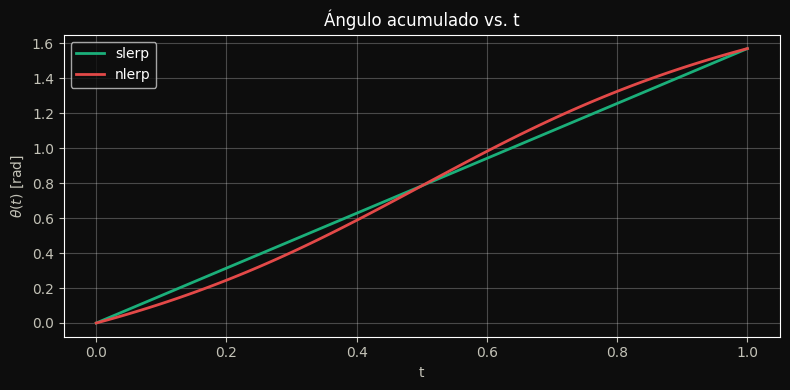

In [18]:
plot_t = np.linspace(0, 1, 101)
plot_q0 = [1, 0, 0, 0]
plot_q1 = [0, 0, 1, 0]
_, plot_theta_s, _ = angular_velocity_error(plot_q0, plot_q1, plot_t, method="slerp")
_, plot_theta_n, _ = angular_velocity_error(plot_q0, plot_q1, plot_t, method="nlerp")

plt.figure(figsize=(8, 4))
plt.plot(plot_t, plot_theta_s, label="slerp", color="#1baf7a", linewidth=2)
plt.plot(plot_t, plot_theta_n, label="nlerp", color="#e34948", linewidth=2)
plt.xlabel("t")
plt.ylabel(r"$\theta(t)$ [rad]")
plt.title("Ángulo acumulado vs. t")
plt.legend()
plt.tight_layout()
plt.show()

Gráfica de velocidad angular instantánea

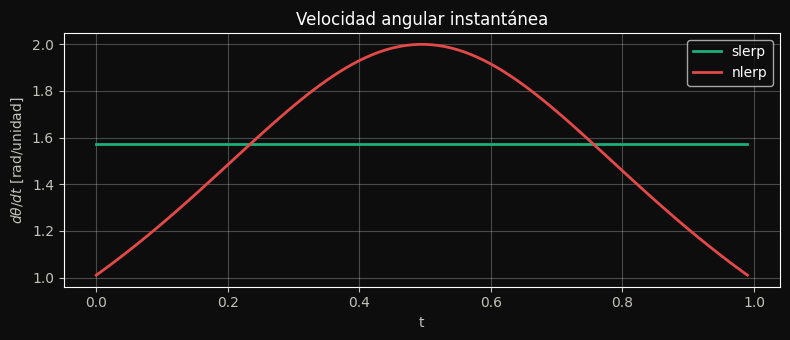

In [19]:
plot_t = np.linspace(0, 1, 101)
plot_q0 = [1, 0, 0, 0]
plot_q1 = [0, 0, 1, 0]
_, _, plot_omega_s = angular_velocity_error(plot_q0, plot_q1, plot_t, method="slerp")
_, _, plot_omega_n = angular_velocity_error(plot_q0, plot_q1, plot_t, method="nlerp")

plt.figure(figsize=(8, 3.5))
plt.plot(plot_t[:-1], plot_omega_s, label="slerp", color="#1baf7a", linewidth=2)
plt.plot(plot_t[:-1], plot_omega_n, label="nlerp", color="#e34948", linewidth=2)
plt.xlabel("t")
plt.ylabel(r"$d\theta/dt$ [rad/unidad]")
plt.title("Velocidad angular instantánea")
plt.legend()
plt.tight_layout()
plt.show()

### 3.4 Ejemplo 3D: interpolación de la orientación de una flecha

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def quat_to_rotmat(q):
    r"""Convierte cuaterniÃƒÂ³n (w, x, y, z) a matriz de rotaciÃƒÂ³n 3x3."""
    w, x, y, z = q
    n = np.dot(q, q)
    if n < 1e-8:
        return np.eye(3)
    s = 2.0 / n
    xs, ys, zs = x * s, y * s, z * s
    wx, wy, wz = w * xs, w * ys, w * zs
    xx, xy, xz = x * xs, x * ys, x * zs
    yy, yz, zz = y * ys, y * zs, z * zs
    return np.array([
        [1 - (yy + zz), xy - wz, xz + wy],
        [xy + wz, 1 - (xx + zz), yz - wx],
        [xz - wy, yz + wx, 1 - (xx + yy)],
    ])

def arrow_points(R, scale=1.0):
    r"""Puntos de una flecha (eje local +Z) transformada por R."""
    base = np.array([
        [0, 0, 0],
        [0, 0, scale],
        [-scale / 10, 0, scale * 9 / 10],
        [scale / 10, 0, scale * 9 / 10],
        [0, -scale / 10, scale * 9 / 10],
        [0, scale / 10, scale * 9 / 10],
    ])
    return (R @ base.T).T

def update_arrow(arrow_obj, R):
    pts = arrow_points(R, scale=1.0)
    arrow_obj.set_data(pts[:, 0], pts[:, 1])
    arrow_obj.set_3d_properties(pts[:, 2])

Orientaciones inicial y final

In [21]:
q0 = [1, 0, 0, 0]  # identidad
axis = np.array([1, 1, 1], dtype=float)
axis = axis / np.linalg.norm(axis)
angle = np.deg2rad(120)
q1 = [
np.cos(angle / 2),
np.sin(angle / 2) * axis[0],
np.sin(angle / 2) * axis[1],
np.sin(angle / 2) * axis[2],
]

t_vals = np.linspace(0, 1, 60)
qs = np.array([slerp(q0, q1, t) for t in t_vals])
qs_nlerp = np.array([nlerp(q0, q1, t) for t in t_vals])

Figura 3D

Text(0.5, 0.92, 'slerp (verde) vs nlerp (rojo)')

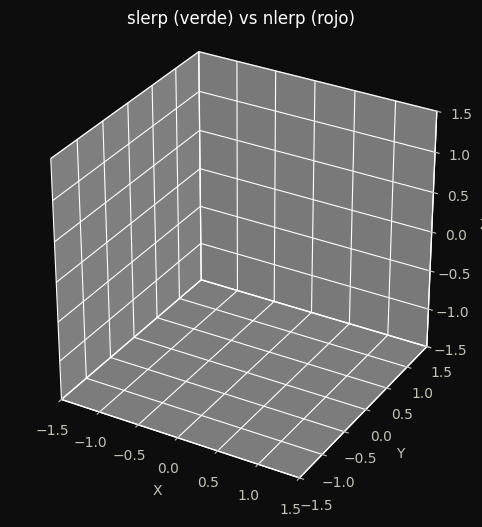

In [22]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.set_box_aspect([1, 1, 1])
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_zlim(-1.5, 1.5)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("slerp (verde) vs nlerp (rojo)")

Eje de rotación

In [23]:
ax.plot([0, axis[0]], [0, axis[1]], [0, axis[2]], color="gray", linestyle="--", linewidth=1, label="Eje")

arrow_s = ax.plot([0, 0], [0, 0], [0, 1], color="#1baf7a", linewidth=3)[0]
arrow_n = ax.plot([0, 0], [0, 0], [0, 1], color="#e34948", linewidth=3)[0]

def animate(frame):
    update_arrow(arrow_s, quat_to_rotmat(qs[frame]))
    update_arrow(arrow_n, quat_to_rotmat(qs_nlerp[frame]))
    return arrow_s, arrow_n

anim = FuncAnimation(fig, animate, frames=len(t_vals), interval=50, blit=False)

In [24]:
anim.save("slerp_vs_nlerp_3d.html", writer="html")
plt.close(fig)

HTML(filename="slerp_vs_nlerp_3d.html")

[09/23/26 09:23:56] INFO     Animation.save using <class 'matplotlib.animation.HTMLWriter'>       animation.py:1076

## Referencias y para profundizar

Shoemake, Ken. (1985). Animating Rotation with Quaternion Curves. ACM SIGGRAPH Computer Graphics, Vol. 19, No. 3, pp. 245-254.

DOI: 10.1145/325165.325242

El artÃƒÂ­culo original que introdujo slerp en grÃƒÂ¡ficos por computadora.

DocumentaciÃƒÂ³n de manim-ce: https://docs.manim.community/en/stable/

Biblioteca de animaciones matemÃƒÂ¡ticas usada en las escenas de este notebook.

scipy.spatial.transform.Rotation: https://docs.scipy.org/doc/scipy/reference/rotations.html

Implementaciones confiables de cuaterniones, slerp y conversiones a matrices de rotaciÃƒÂ³n.

Extensiones interesantes:

Splines de cuaterniones (squad) para interpolaciÃƒÂ³n $C^1$.
InterpolaciÃƒÂ³n en el espacio de Lie $\mathfrak{so}(3)$ mediante logaritmo y exponencial.
Manejo de mÃƒÂºltiples keyframes y control de velocidad mediante easing.